# Day 11 — Classification Machine Learning Practice

**Linkific AI/ML Internship — Month 1 Training**  
**Intern:** Shri Sanjaykumar V  

---

### 🎯 Objectives
1. Understand the basics of **Classification problems** in Supervised Learning.
2. Train a **Logistic Regression** model.
3. Train a **Decision Tree** model.
4. Compare both models using **Accuracy**.
5. Record simple observations from the results.


## 1. What is Classification?

In Machine Learning, **Classification** is a supervised learning approach where the target variable consists of discrete categories or labels (e.g., predicting flower species: *Setosa*, *Versicolor*, or *Virginica*).

This differs fundamentally from **Regression** (covered on Day 10), which predicts continuous numerical values (such as salary or house price).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Iris Dataset

We use Scikit-learn's standard **Iris dataset**, a classic benchmark dataset containing 150 flower samples across 3 species with 4 continuous measurements per sample.


In [2]:
# Load the Iris dataset from Scikit-learn
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
species_map = {idx: name for idx, name in enumerate(iris.target_names)}
df["species"] = df["target"].map(species_map)

print(f"Iris dataset loaded: {df.shape[0]} samples, {len(iris.feature_names)} features, {len(iris.target_names)} classes.")


Iris dataset loaded: 150 samples, 4 features, 3 classes.


## 3. Dataset Overview

Checking the shape, class distribution, and first 5 rows of the dataset.


In [3]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Class distribution:")
print(df["species"].value_counts().to_string())
print("\nFirst 5 rows:")
df.head(5)


Dataset Shape: 150 rows, 6 columns

Class distribution:
species
setosa        50
versicolor    50
virginica     50

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 4. Feature and Target Selection

- **Features ($X$):** All 4 flower measurements (sepal length, sepal width, petal length, petal width).
- **Target ($y$):** The species category code (0: Setosa, 1: Versicolor, 2: Virginica).


In [4]:
# Select input features (X) and target (y)
X = df[iris.feature_names]
y = df["target"]

print("Features (X):", list(X.columns))
print("Target classes:", list(iris.target_names))


Features (X): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## 5. Train-Test Split

We split the data into **80% training** (120 samples) and **20% testing** (30 samples).  
Using `stratify=y` ensures each class is equally represented in both sets. The same test data was used for both models for comparison.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set:  {len(X_test)} samples")
print("The same test data was used for both models for comparison.")


Training set: 120 samples
Testing set:  30 samples
The same test data was used for both models for comparison.


## 6. Logistic Regression Model

Logistic Regression is a popular linear classification algorithm that estimates class probabilities.
We instantiate the model with `max_iter=200`, train it using `.fit()`, predict using `.predict()`, and evaluate accuracy.


In [6]:
# Instantiate and train Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train, y_train)

# Make predictions on test data
logistic_pred = logistic_model.predict(X_test)

# Calculate accuracy dynamically
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_correct = (y_test == logistic_pred).sum()

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f} ({logistic_accuracy * 100:.2f}%)")
print(f"Correct Predictions: {logistic_correct} out of {len(y_test)}")


Logistic Regression Accuracy: 0.9667 (96.67%)
Correct Predictions: 29 out of 30


## 7. Decision Tree Model

A Decision Tree is a non-linear classifier that makes decisions by asking a series of simple if-else questions based on feature values.
We instantiate `DecisionTreeClassifier(random_state=42)`, train it using `.fit()`, predict using `.predict()`, and evaluate accuracy.


In [7]:
# Instantiate and train Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

# Make predictions on test data
tree_pred = decision_tree.predict(X_test)

# Calculate accuracy dynamically
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_correct = (y_test == tree_pred).sum()

print(f"Decision Tree Accuracy:       {tree_accuracy:.4f} ({tree_accuracy * 100:.2f}%)")
print(f"Correct Predictions: {tree_correct} out of {len(y_test)}")


Decision Tree Accuracy:       0.9333 (93.33%)
Correct Predictions: 28 out of 30


## 8. Accuracy Comparison

We compare both models side-by-side using an accuracy table and a bar chart.


In [8]:
# Build dynamic accuracy comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Correct / Total": [f"{(y_test == logistic_pred).sum()} / {len(y_test)}", f"{(y_test == tree_pred).sum()} / {len(y_test)}"],
    "Accuracy Score": [logistic_accuracy, tree_accuracy],
    "Accuracy (%)": [f"{logistic_accuracy * 100:.2f}%", f"{tree_accuracy * 100:.2f}%"]
})

print("Model Accuracy Comparison Table:")
try:
    display(comparison)
except (NameError, TypeError):
    print(comparison.to_string(index=False))

# Sample predictions comparison on first 10 test samples
species_names = iris.target_names
sample_preds = pd.DataFrame({
    "Actual Class": [species_names[i] for i in y_test.values[:10]],
    "Logistic Regression": [species_names[i] for i in logistic_pred[:10]],
    "Decision Tree": [species_names[i] for i in tree_pred[:10]]
})
print("\nSample Predictions on First 10 Test Samples:")
try:
    display(sample_preds)
except (NameError, TypeError):
    print(sample_preds.to_string(index=False))


Model Accuracy Comparison Table:
              Model Correct / Total  Accuracy Score Accuracy (%)
Logistic Regression         29 / 30        0.966667       96.67%
      Decision Tree         28 / 30        0.933333       93.33%

Sample Predictions on First 10 Test Samples:
Actual Class Logistic Regression Decision Tree
      setosa              setosa        setosa
   virginica           virginica     virginica
  versicolor          versicolor    versicolor
  versicolor          versicolor    versicolor
      setosa              setosa        setosa
  versicolor          versicolor    versicolor
      setosa              setosa        setosa
      setosa              setosa        setosa
   virginica           virginica     virginica
  versicolor          versicolor    versicolor


Model,Correct / Total,Accuracy Score,Accuracy (%)
Logistic Regression,29 / 30,0.966667,96.67%
Decision Tree,28 / 30,0.933333,93.33%


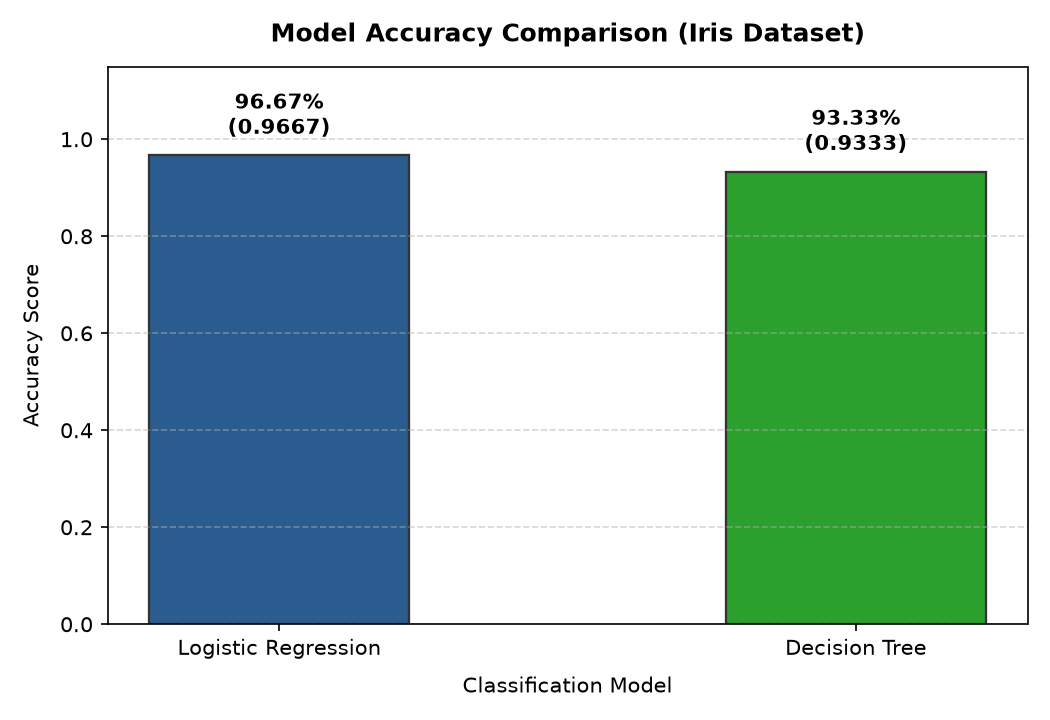

In [9]:
# Plot model accuracy comparison bar chart
plt.figure(figsize=(7, 4.8), dpi=150)
models = comparison["Model"].tolist()
accuracies = comparison["Accuracy Score"].tolist()

bars = plt.bar(models, accuracies, color=["#2b5c8f", "#2ca02c"], width=0.45, edgecolor="#333333", linewidth=1.1)
plt.title("Model Accuracy Comparison (Iris Dataset)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Classification Model", fontsize=10, labelpad=8)
plt.ylabel("Accuracy Score", fontsize=10, labelpad=8)
plt.ylim(0, 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.03,
        f"{acc * 100:.2f}%\n({acc:.4f})",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.show()


## 9. Observations

The following observations are calculated dynamically from runtime predictions:


In [10]:
# Dynamic Observations (Computed at Runtime)
if logistic_accuracy > tree_accuracy:
    better_model = "Logistic Regression"
    diff_pct = (logistic_accuracy - tree_accuracy) * 100
    better_text = f"{better_model} performed slightly better on this test split (+{diff_pct:.2f}%)."
elif tree_accuracy > logistic_accuracy:
    better_model = "Decision Tree"
    diff_pct = (tree_accuracy - logistic_accuracy) * 100
    better_text = f"{better_model} performed slightly better on this test split (+{diff_pct:.2f}%)."
else:
    better_text = "Both models achieved the same accuracy on this test split."

print("=" * 60)
print("OBSERVATIONS (DYNAMICALLY COMPUTED)")
print("=" * 60)
print(f"1. Logistic Regression achieved {logistic_accuracy * 100:.2f}% accuracy ({logistic_correct}/{len(y_test)} correct).")
print(f"2. Decision Tree achieved {tree_accuracy * 100:.2f}% accuracy ({tree_correct}/{len(y_test)} correct).")
print(f"3. {better_text}")
print("=" * 60)


OBSERVATIONS (DYNAMICALLY COMPUTED)
1. Logistic Regression achieved 96.67% accuracy (29/30 correct).
2. Decision Tree achieved 93.33% accuracy (28/30 correct).
3. Logistic Regression performed slightly better on this test split (+3.33%).


## 10. Conclusion

- **Workflow:** Successfully followed the complete classification workflow: data loading $\rightarrow$ train/test split $\rightarrow$ model training (`.fit`) $\rightarrow$ prediction (`.predict`) $\rightarrow$ accuracy evaluation (`accuracy_score`).
- **Comparison:** Both models performed very well on the Iris dataset (>93% accuracy), with Logistic Regression achieving slightly higher accuracy on this test split.
- **Key Takeaway:** Evaluating multiple models on the exact same test data provides an objective way to compare model performance.
